# Snabb EDA: AI4I 2020 Predictive Maintenance Dataset

**Källa:** UCI Machine Learning Repository, https://archive.ics.uci.edu/dataset/601  
**DOI:** 10.24432/C5HS5C  
**Licens:** CC BY 4.0 (fri användning, källan ska anges)  
**Obs:** Syntetiskt dataset som ska efterlikna verklig underhållsdata.  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
 
URL = "https://archive.ics.uci.edu/static/public/601/ai4i+2020+predictive+maintenance+dataset.zip"
df = pd.read_csv(URL)  # pandas packar upp zip-filen automatiskt
 
print(df.shape)
df.info()
df.head()

(10000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Målvariabel och felorsaker

In [2]:
failure_modes = ["TWF", "HDF", "PWF", "OSF", "RNF"]
 
print("Maskinfel totalt:", df["Machine failure"].sum(),
      f"({df['Machine failure'].mean():.2%} av raderna)")
print(df[failure_modes].sum())
 
# Stämmer "Machine failure" med felorsakerna?
any_mode = df[failure_modes].any(axis=1).astype(int)
print("\nFel utan angiven orsak:", ((df["Machine failure"] == 1) & (any_mode == 0)).sum())
print("Orsak utan registrerat fel:", ((df["Machine failure"] == 0) & (any_mode == 1)).sum())

Maskinfel totalt: 339 (3.39% av raderna)
TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

Fel utan angiven orsak: 9
Orsak utan registrerat fel: 18


## Produkttyp (L/M/H) och felfrekvens

In [3]:
print(df["Type"].value_counts())
print(df.groupby("Type")["Machine failure"].mean().round(4))

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64
Type
H    0.0209
L    0.0392
M    0.0277
Name: Machine failure, dtype: float64


## Fördelning av de numeriska variablerna, fel mot inga fel

       Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
count              10000.0                 10000.00                10000.00   
mean                 300.0                   310.01                 1538.78   
std                    2.0                     1.48                  179.28   
min                  295.3                   305.70                 1168.00   
25%                  298.3                   308.80                 1423.00   
50%                  300.1                   310.10                 1503.00   
75%                  301.5                   311.10                 1612.00   
max                  304.5                   313.80                 2886.00   

       Torque [Nm]  Tool wear [min]  
count     10000.00         10000.00  
mean         39.99           107.95  
std           9.97            63.65  
min           3.80             0.00  
25%          33.20            53.00  
50%          40.10           108.00  
75%          46.80    

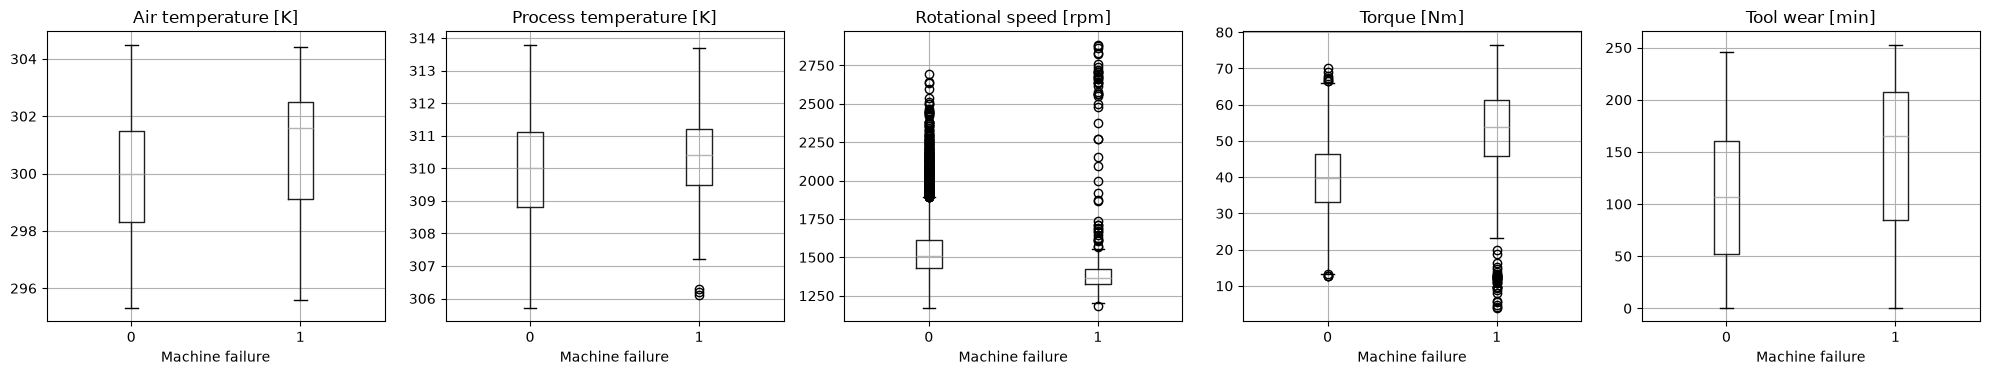

In [4]:
num_cols = ["Air temperature [K]", "Process temperature [K]",
            "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]
 
print(df[num_cols].describe().round(2))
 
fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 4))
for ax, col in zip(axes, num_cols):
    df.boxplot(column=col, by="Machine failure", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Machine failure")
plt.suptitle("")
plt.tight_layout()
plt.show()

## Är felen regelstyrda? (syntetisk data)

Datasetets beskrivning anger exakta regler för flera felorsaker.  
Kontrollerar hur väl reglerna förklarar felen.

In [5]:
temp_diff = df["Process temperature [K]"] - df["Air temperature [K]"]
power_w = df["Torque [Nm]"] * df["Rotational speed [rpm]"] * 2 * 3.14159 / 60
strain = df["Tool wear [min]"] * df["Torque [Nm]"]
strain_limit = df["Type"].map({"L": 11000, "M": 12000, "H": 13000})
 
rule_hdf = (temp_diff < 8.6) & (df["Rotational speed [rpm]"] < 1380)
rule_pwf = (power_w < 3500) | (power_w > 9000)
rule_osf = strain > strain_limit
 
for name, rule in [("HDF", rule_hdf), ("PWF", rule_pwf), ("OSF", rule_osf)]:
    print(f"{name}: regeln säger fel {rule.sum()} gånger, datan har {df[name].sum()}, "
          f"överensstämmelse {(rule.astype(int) == df[name]).mean():.4f}")

HDF: regeln säger fel 115 gånger, datan har 115, överensstämmelse 1.0000
PWF: regeln säger fel 95 gånger, datan har 95, överensstämmelse 1.0000
OSF: regeln säger fel 98 gånger, datan har 98, överensstämmelse 1.0000


## Korrelationer

In [6]:
print(df[num_cols + ["Machine failure"]].corr().round(2))

                         Air temperature [K]  Process temperature [K]  \
Air temperature [K]                     1.00                     0.88   
Process temperature [K]                 0.88                     1.00   
Rotational speed [rpm]                  0.02                     0.02   
Torque [Nm]                            -0.01                    -0.01   
Tool wear [min]                         0.01                     0.01   
Machine failure                         0.08                     0.04   

                         Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  \
Air temperature [K]                        0.02        -0.01             0.01   
Process temperature [K]                    0.02        -0.01             0.01   
Rotational speed [rpm]                     1.00        -0.88             0.00   
Torque [Nm]                               -0.88         1.00            -0.00   
Tool wear [min]                            0.00        -0.00             1.00   
Ma

## Sammanfattning av EDA

### Datasetet i korthet
- 10 000 rader, 14 kolumner, inga saknade värden.
- `UDI` och `Product ID` är identifierare och ska inte användas som indata.
- Datasetet är **syntetiskt**, alltså genererat för att efterlikna underhållsdata, inte uppmätt i en riktig maskin.
- UCI märker det som tidsserie, men det finns ingen tidsstämpel. Raderna är oberoende observationer.
- **Licens:** CC BY 4.0. Fri användning med källhänvisning (DOI 10.24432/C5HS5C).

### Målvariabel
- 339 maskinfel av 10 000 rader (**3,39 %**). Stark obalans: en modell som alltid säger "inget fel" får 96,6 % accuracy. Mät därför med recall, precision, F1 eller PR-AUC.
- Felorsakerna summerar till 373, alltså fler än 339. Vissa fel har flera orsaker samtidigt.
- **Brus i etiketterna:** 9 fel saknar angiven orsak, och 18 rader har en orsak men inget registrerat fel (troligen främst RNF).
- Beskrivningen på UCI anger 120 verktygsslitagefel (TWF), men datan har 46. Dokumentationen och datan stämmer alltså inte helt överens.
- Produkttyp L har högst felfrekvens (3,9 %), sedan M (2,8 %) och H (2,1 %). Det förklaras av att gränsen för överbelastning (OSF) är lägst för L.

### Felen följer exakta regler
Reglerna i datasetets beskrivning reproducerar etiketterna **helt**:

| Felorsak | Regel | Överensstämmelse |
|---|---|---|
| HDF (värme) | temperaturskillnad < 8,6 K och varvtal < 1380 rpm | 100 % |
| PWF (effekt) | effekt < 3500 W eller > 9000 W | 100 % |
| OSF (överbelastning) | slitage × vridmoment över typens gräns | 100 % |

Det gäller 308 av de 373 felorsakerna. Resterande är TWF (slumpmässigt inom ett slitageintervall) och RNF (helt slumpmässiga).

**Konsekvens:** En modell som får rätt variabler "hittar" i praktiken bara reglerna som användes för att skapa datan. Höga resultat säger då mer om hur datasetet genererades än om verkligt underhåll.

### Samband mellan variabler
- Lufttemperatur och processtemperatur korrelerar 0,88, och varvtal och vridmoment −0,88. Båda sambanden är inbyggda i hur datan genererades.
- Den linjära korrelationen med maskinfel är svag (högst vridmoment, 0,19), men boxplottarna visar att felen ligger i **ytterkanterna**: både högt och lågt vridmoment, lågt varvtal (HDF) och högt varvtal (PWF), samt högt slitage. Sambanden är alltså icke-linjära.
- En logistisk regression på råvariablerna kommer därför att prestera sämre, medan trädmodeller eller härledda variabler (effekt, temperaturskillnad, slitage × vridmoment) fångar reglerna nästan perfekt.

### Kommentarer på förslaget från Gemini
- **Problem och användare:** Rimligt formulerat. Modellen kan bedöma felrisken i ett givet driftläge och därmed stödja underhållsbeslut, till exempel verktygsbyte eller sänkt belastning. Däremot finns ingen tidsdimension, så den kan inte förutsäga *när* ett fel inträffar, och datan innehåller inte sensorbortfall.
- **Baseline med tröskelvärden:** Eftersom felen *är* tröskelregler blir en regelbaserad baseline i praktiken facit för HDF, PWF och OSF. Det blir svårt för XGBoost eller Random Forest att visa något mervärde.
- **NASA Turbofan (C-MAPSS):** Också simulerad data, men en riktig tidsserie med gradvis nedbrytning. Där är uppgiften att förutsäga återstående livslängd (RUL), vilket ligger närmare verkligt prediktivt underhåll. Ett annat problem än AI4I.
- **Kolumnerna TWF, HDF, PWF, OSF och RNF** måste tas bort som indata. De är orsakerna till målvariabeln och ger annars fullständigt dataläckage.

### Frågeställning
Projektet blir mer intressant om frågeställningen tar hänsyn till att datan är regelstyrd, till exempel:
- Hur mycket förbättrar domänbaserade variabler (effekt, temperaturskillnad, belastning) en enkel modell jämfört med råvariabler?
- Hur väl klarar modellerna de fel som *inte* är regelstyrda (TWF, RNF)?
- Hur påverkar obalansen valet av tröskel och mått?

### Jämförelse med gruvdatan (Quality Prediction in a Mining Process)
| | AI4I 2020 | Gruvdatan |
|---|---|---|
| Typ av data | Syntetisk | Verklig processdata |
| Storlek | 10 000 rader, rent | ca 4 100 timmar efter aggregering |
| Uppgift | Klassificering | Regression / tidsserieprognos |
| Datakvalitet | Inga saknade värden, visst etikettbrus | Lucka, fastfrusna sensorer, upprepade labbvärden |
| Risk | Resultaten speglar genereringsreglerna | Svårt att slå en enkel baseline |
| Styrka | Snabbt att komma igång | Verkliga problem och tydlig koppling till industrin |